# Practical task. Logistic regression

Client applies for a new credit card. The task of the model used by the bank is to assess the client’s **creditworthiness**, i.e., the probability of a positive credit history, and decide whether to approve or reject the credit card application.

**Data description:**

* **card**: **target variable**, whether the application was approved ("yes" or "no");
* **reports**: number of negative credit histories;
* **age**: client’s age;
* **income**: annual income (divided by 10,000);
* **share**: ratio of monthly credit card expenses to annual income;
* **expenditure**: average monthly credit card expenses;
* **owner**: "yes" if the client owns housing, "no" if renting;
* **selfempl**: "yes" if self-employed, "no" otherwise;
* **dependents**: number of dependents supported by the client plus one;
* **months**: number of months the client has lived at the current address;
* **majorcards**: number of credit cards the client has;
* **active**: number of active credit accounts.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
file_path= '/content/drive/My Drive/credit_card_data.csv'
df = pd.read_csv(file_path)
df

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1314,yes,0,33.58333,4.5660,0.002146,7.333333,yes,no,0,94,1,19
1315,no,5,23.91667,3.1920,0.000376,0.000000,no,no,3,12,1,5
1316,yes,0,40.58333,4.6000,0.026513,101.298300,yes,no,2,1,1,2
1317,yes,0,32.83333,3.7000,0.008999,26.996670,no,yes,0,60,1,7


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1319 non-null   object 
 1   reports      1319 non-null   int64  
 2   age          1319 non-null   float64
 3   income       1319 non-null   float64
 4   share        1319 non-null   float64
 5   expenditure  1319 non-null   float64
 6   owner        1319 non-null   object 
 7   selfemp      1319 non-null   object 
 8   dependents   1319 non-null   int64  
 9   months       1319 non-null   int64  
 10  majorcards   1319 non-null   int64  
 11  active       1319 non-null   int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 123.8+ KB


In [4]:
df.isna().sum()

,0
card,0
reports,0
age,0
income,0
share,0
expenditure,0
owner,0
selfemp,0
dependents,0
months,0


In [5]:
df["age"] = df["age"].astype(int)
df

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32,9.7867,0.067051,546.503300,yes,no,2,64,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1314,yes,0,33,4.5660,0.002146,7.333333,yes,no,0,94,1,19
1315,no,5,23,3.1920,0.000376,0.000000,no,no,3,12,1,5
1316,yes,0,40,4.6000,0.026513,101.298300,yes,no,2,1,1,2
1317,yes,0,32,3.7000,0.008999,26.996670,no,yes,0,60,1,7


In [6]:
df["owner"] = df["owner"].map({"no": 0, "yes": 1})
df["selfemp"] = df["selfemp"].map({"no": 0, "yes": 1})
df["card"] = df["card"].map({"no": 0, "yes": 1})

df

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37,4.5200,0.033270,124.983300,1,0,3,54,1,12
1,1,0,33,2.4200,0.005217,9.854167,0,0,3,34,1,13
2,1,0,33,4.5000,0.004156,15.000000,1,0,4,58,1,5
3,1,0,30,2.5400,0.065214,137.869200,0,0,0,25,1,7
4,1,0,32,9.7867,0.067051,546.503300,1,0,2,64,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1314,1,0,33,4.5660,0.002146,7.333333,1,0,0,94,1,19
1315,0,5,23,3.1920,0.000376,0.000000,0,0,3,12,1,5
1316,1,0,40,4.6000,0.026513,101.298300,1,0,2,1,1,2
1317,1,0,32,3.7000,0.008999,26.996670,0,1,0,60,1,7


Підготуй дані для побудови моделі.

Розділи дані на тренувальні та тестові.

Проведи стандартизацію даних для вирівнення масштабів.

Навчи модель логістичної регресії із гіперпараметрами за замовчуванням. За потреби зміни дефолтні параметри.

Виведи значення вагових коефіцієнтів моделі. Побудуй двокольорову стовпчикову діаграму, як у прикладі в теорії.
Які змінні позитивно впливають на схвалення кредитної заявки, а які - негативно? Зроби висновки щодо важливості змінних у моделі.


In [7]:
X = df.drop(["card"], axis=1)
y = df["card"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2024)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [8]:
coefficients = model.coef_[0]
feature_names = X.columns
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coefficients
}).sort_values(by="Importance")

print(importance_df)

        Feature  Importance
0       reports   -1.965070
7    dependents   -0.277518
8        months   -0.051604
6       selfemp    0.019269
1           age    0.099718
2        income    0.148137
5         owner    0.201460
9    majorcards    0.227381
10       active    0.501858
4   expenditure    4.847761
3         share    5.728397


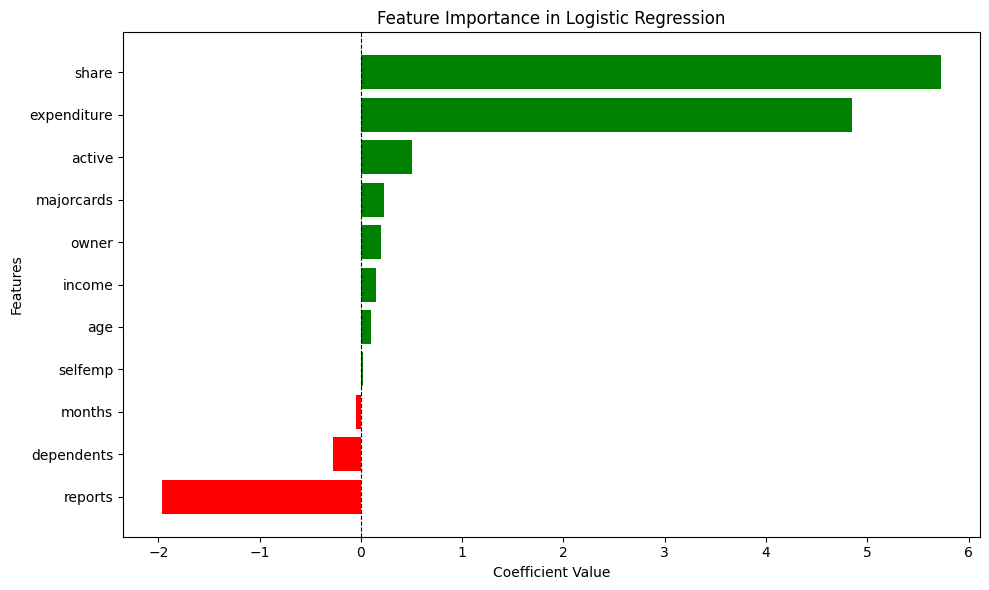

In [9]:
plt.figure(figsize=(10, 6))
colors = ["green" if val > 0 else "red" for val in importance_df["Importance"]]
plt.barh(importance_df["Feature"], importance_df["Importance"], color=colors)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Feature Importance in Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()

plt.show()

У моделі є три найвпливовіші змінні:

* **share** (коефіцієнт 5,73): чим вищий співвідношення витрат за кредитною карткою до річного доходу, тим більша ймовірність схвалення заявки.
* **expenditure** (4,85): вищі середні щомісячні витрати за кредитною карткою збільшують шанси на схвалення.
* **reports** (-1,96): чим більше негативних кредитних звітів має клієнт, тим менші його шанси на схвалення.

Змінні, які майже не впливають на рішення банку щодо схвалення заявки:

* **age** клієнта;
* **Number of months** проживання за поточною адресою;
* статус **Employment** або **self-employment**.

